# RealMLP Approach on Predicting Heart Disease

- PB:
- Purpose:
    - Remove HPO and measure LB
    -

### Package import

In [1]:
!pip install pytabkit -q

from pathlib import Path
import json
import zipfile
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import warnings
from sklearn.metrics import roc_auc_score
from pytabkit import RealMLP_TD_Classifier
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ---- Config ----
COMP_SLUG = "playground-series-s6e2"
KAGGLE_COMP_DIR = Path("/kaggle/input/competitions/playground-series-s6e2")
KAGGLE_EXT_PATH = Path("/kaggle/input/datasets/neurocipher/heartdisease/Heart_Disease_Prediction.csv")

LOCAL_DATA_DIR = Path("data/raw")
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

NEED_FILES = ["train.csv", "test.csv", "sample_submission.csv"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.4 MB/s eta 0:00:00


In [2]:
def run(cmd: list[str]) -> None:
    p = subprocess.run(cmd, capture_output=True, text=True)
    p.check_returncode()


def ensure_kaggle_cli() -> None:
    try:
        pass
    except Exception:
        subprocess.check_call(["pip", "-q", "install", "kaggle"])


def ensure_kaggle_json_interactive_colab(dst: Path = Path("/content/kaggle.json")) -> Path:
    """
    In Colab: open upload dialog if /content/kaggle.json is missing.
    In non-Colab: just require the file to exist.
    """
    if dst.exists():
        print("Found:", dst)
        return dst

    try:
        from google.colab import files  # type: ignore
    except Exception:
        raise FileNotFoundError(
            f"{dst} not found. Please place kaggle.json at {dst} (Colab) "
            "or provide credentials another way."
        )

    print("Upload your kaggle.json (Kaggle -> Account -> API -> Create New Token)")
    uploaded = files.upload()
    cand = None
    if "kaggle.json" in uploaded:
        cand = "kaggle.json"
    else:
        for name in uploaded.keys():
            if name.endswith(".json"):
                cand = name
                break
    if cand is None:
        raise FileNotFoundError("Upload failed: no .json file received.")

    Path(cand).rename(dst)
    print("Saved to:", dst)
    return dst


def install_kaggle_json(src: Path) -> None:
    """
    Copy /content/kaggle.json -> ~/.kaggle/kaggle.json (chmod 600)
    """
    if not src.exists():
        raise FileNotFoundError(f"{src} not found.")

    dst_dir = Path.home() / ".kaggle"
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / "kaggle.json"

    dst.write_bytes(src.read_bytes())
    try:
        dst.chmod(0o600)
    except Exception:
        pass

    cfg = json.loads(dst.read_text())
    if "username" not in cfg or "key" not in cfg:
        raise ValueError("kaggle.json is missing 'username' or 'key'.")
    print(f"Installed kaggle.json for user: {cfg['username']}")


def local_data_ready(data_dir: Path) -> bool:
    return all((data_dir / f).exists() for f in NEED_FILES)


def download_competition_to(data_dir: Path) -> None:
    """
    Download competition zip(s) and extract into data_dir.
    Assumes kaggle CLI + credentials are ready.
    """
    run(["kaggle", "config", "view"])
    run(["kaggle", "competitions", "download", "-c", COMP_SLUG, "-p", str(data_dir), "--force"])

    zips = list(data_dir.glob("*.zip"))
    if not zips:
        raise FileNotFoundError(f"No zip found in {data_dir} after download.")

    for zp in zips:
        with zipfile.ZipFile(zp, "r") as zf:
            zf.extractall(data_dir)
        print("Unzipped:", zp.name)

    if not local_data_ready(data_dir):
        missing = [f for f in NEED_FILES if not (data_dir / f).exists()]
        raise FileNotFoundError(f"Download/unzip finished but missing: {missing}")


In [3]:
if KAGGLE_COMP_DIR.exists():
    DATA_SRC = "kaggle"
    data_dir = KAGGLE_COMP_DIR
    print("Using Kaggle mounted competition data:", data_dir)
else:
    DATA_SRC = "local"
    data_dir = LOCAL_DATA_DIR
    if local_data_ready(data_dir):
        print("Using local data (already present):", data_dir)
    else:
        print("Local data missing -> download using kaggle.json")
        ensure_kaggle_cli()
        kaggle_json_src = ensure_kaggle_json_interactive_colab(Path("/content/kaggle.json"))
        install_kaggle_json(kaggle_json_src)
        download_competition_to(data_dir)
        print("Download complete -> using local data:", data_dir)


# ---- Load ----
train = pd.read_csv(data_dir / "train.csv")
test  = pd.read_csv(data_dir / "test.csv")
sub   = pd.read_csv(data_dir / "sample_submission.csv")

# external dataset: only available if mounted on Kaggle; optional
original = pd.read_csv(KAGGLE_EXT_PATH) if KAGGLE_EXT_PATH.exists() else None

print("train:", train.shape, "test:", test.shape, "sub:", sub.shape, "original:", None if original is None else original.shape)
print("DATA_SRC:", DATA_SRC)


Local data missing -> download using kaggle.json
Upload your kaggle.json (Kaggle -> Account -> API -> Create New Token)


Saving kaggle.json to kaggle.json
Saved to: /content/kaggle.json
Installed kaggle.json for user: bloodymonday
Unzipped: playground-series-s6e2.zip
Download complete -> using local data: data/raw
train: (630000, 15) test: (270000, 14) sub: (270000, 2) original: None
DATA_SRC: local


In [4]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.set_float32_matmul_precision("high")
N_FOLDS = 5
USE_ALL_CAT = True

print(f"Using device: {DEVICE}")


Using device: cuda


### Data download

In [5]:
display(train.head())
display(test.head())
display(sub.head())

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [6]:
# Shapes
print("train:", train.shape)
print("test:", test.shape)

# Column diffs
train_cols = set(train.columns)
test_cols = set(test.columns)
print("Only in train:", sorted(train_cols - test_cols))
print("Only in test:", sorted(test_cols - train_cols))

# dtypes
train.dtypes.to_frame("dtype").head(30)


train: (630000, 15)
test: (270000, 14)
Only in train: ['Heart Disease']
Only in test: []


,dtype
id,int64
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64


### Data Preprocessing

In [7]:
def encode_target_strict(y: pd.Series) -> pd.Series:
    """Map common string labels to {0,1}. Raises if unknown."""
    mapping_candidates = [
        {"No": 0, "Yes": 1},
        {"N": 0, "Y": 1},
        {"Negative": 0, "Positive": 1},
        {"Absent": 0, "Present": 1},
        {"Absence": 0, "Presence": 1},
        {0: 0, 1: 1},
        {"0": 0, "1": 1},
    ]
    uniq = set(pd.Series(y).dropna().unique().tolist())
    for mp in mapping_candidates:
        if uniq.issubset(set(mp.keys())):
            return pd.Series(y).map(mp).astype("int8")
    raise ValueError(f"Unknown target labels: {sorted(list(uniq))}")


# ---- target ----
train["Heart Disease"] = encode_target_strict(train["Heart Disease"])
if original is not None and "Heart Disease" in original.columns:
    original["Heart Disease"] = encode_target_strict(original["Heart Disease"])

TARGET_COL = "Heart Disease"
ID_COL = "id"

BASE_FEATURES = [c for c in train.columns if c not in [TARGET_COL, ID_COL]]

# Canonical S6E2 semantic categoricals (keep as category for embeddings/encoding)
CANONICAL_CAT = {
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium",
}

def split_cols(df: pd.DataFrame):
    base = [c for c in df.columns if c not in [TARGET_COL, ID_COL]]
    cat = [c for c in base if c in CANONICAL_CAT]
    num = [c for c in base if c not in cat]
    return cat, num


def add_external_target_stats(df: pd.DataFrame, original_df: pd.DataFrame | None) -> pd.DataFrame:
    """Merge group-wise target stats from the external/original dataset.
    Safe in Playground comps because original_df labels are not the competition labels.
    """
    if original_df is None:
        return df.copy()

    out = df.copy()
    initial_rows = len(out)

    for col in BASE_FEATURES:
        if col not in original_df.columns:
            continue

        stats = (
            original_df.groupby(col)[TARGET_COL]
            .agg(["mean", "median", "std", "skew", "count"])
            .reset_index()
        )
        stats.columns = [col] + [f"orig_{col}_{s}" for s in ["mean", "median", "std", "skew", "count"]]

        out = out.merge(stats, on=col, how="left")
        if len(out) != initial_rows:
            raise ValueError(f"Merge expanded rows for column {col}! {initial_rows} -> {len(out)}")

        # fill NAs for unseen values
        global_mean = float(original_df[TARGET_COL].mean())
        global_median = float(original_df[TARGET_COL].median())
        fill = {
            f"orig_{col}_mean": global_mean,
            f"orig_{col}_median": global_median,
            f"orig_{col}_std": 0.0,
            f"orig_{col}_skew": 0.0,
            f"orig_{col}_count": 0.0,
        }
        out = out.fillna(value=fill)

    return out


def add_frequency_encoding(train_df: pd.DataFrame, test_df: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Add {col}_freq columns using combined train+test frequencies (unsupervised, safe)."""
    tr = train_df.copy()
    te = test_df.copy()

    combined = pd.concat([tr[cols], te[cols]], axis=0, ignore_index=True)
    for col in cols:
        freq = combined[col].value_counts(dropna=False)
        tr[f"{col}_freq"] = tr[col].map(freq).astype("float32")
        te[f"{col}_freq"] = te[col].map(freq).astype("float32")
    return tr, te


def add_binned_numerics(train_df: pd.DataFrame, test_df: pd.DataFrame, num_cols: list[str], n_bins: int = 10):
    tr = train_df.copy()
    te = test_df.copy()

    for col in num_cols:
        allv = pd.concat([tr[col], te[col]], axis=0, ignore_index=True)

        # If low cardinality, just reuse as "bin" (stable int codes)
        if allv.nunique(dropna=False) <= n_bins:
            tr[f"{col}_bin"] = pd.Series(tr[col]).astype("int32", errors="ignore")
            te[f"{col}_bin"] = pd.Series(te[col]).astype("int32", errors="ignore")
            continue

        try:
            bins = pd.qcut(allv.rank(method="first"), q=n_bins, labels=False, duplicates="drop")
        except Exception:
            bins = pd.cut(allv, bins=n_bins, labels=False, duplicates="drop")

        tr[f"{col}_bin"] = bins.iloc[:len(tr)].astype("int16")
        te[f"{col}_bin"] = bins.iloc[len(tr):].astype("int16")

    return tr, te


def build_features(
    train_fe: pd.DataFrame,
    test_fe: pd.DataFrame,
    cat_cols: list[str],
    num_cols: list[str],
    use_bins: bool,
):
    tr = train_fe.copy()
    te = test_fe.copy()

    if use_bins:
        # Add binned versions of continuous numerics (helps linear/MLP; low risk for GBDT too)
        # Important: keep 'orig_*' stats as numeric; they are already in num_cols here.
        # bin only "base continuous" numerics (exclude orig_* stats)
        num_cols_for_bins = [c for c in num_cols if not c.startswith("orig_")]
        tr, te = add_binned_numerics(tr, te, num_cols_for_bins, n_bins=10)

    print(f"Train Shape after FE: {tr.shape}")
    print(f"Test Shape after FE:  {te.shape}")

    # ---- Build X/y with clean dtypes ----
    drop_tr = [c for c in [TARGET_COL, ID_COL] if c in tr.columns]
    drop_te = [c for c in [ID_COL] if c in te.columns]

    X = tr.drop(columns=drop_tr).copy()
    X_test = te.drop(columns=drop_te).copy()
    y = tr[TARGET_COL].copy()

    bin_cols = [c for c in X.columns if c.endswith("_bin")]

    cat_cols_final = [c for c in X.columns if c in cat_cols] + (bin_cols if use_bins else [])
    num_cols_final = [c for c in X.columns if c not in cat_cols_final]

    for c in cat_cols_final:
        combined = pd.concat([X[c], X_test[c]], axis=0, ignore_index=True)
        cats = pd.Categorical(combined).categories
        X[c] = pd.Categorical(X[c], categories=cats)
        X_test[c] = pd.Categorical(X_test[c], categories=cats)

    for c in num_cols_final:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")
        X_test[c] = pd.to_numeric(X_test[c], errors="coerce").astype("float32")

    return X, X_test, y, cat_cols_final, num_cols_final


# ---- Feature engineering (per EDA) ----
train_fe = add_external_target_stats(train, original)
test_fe  = add_external_target_stats(test, original)

cat_cols, num_cols = split_cols(train_fe)

# Frequency encoding for semantic categoricals
train_fe, test_fe = add_frequency_encoding(train_fe, test_fe, cat_cols)

CONFIGS = {
    "categorical_binned": True,
    "numeric_continuous": False,
}

features = {}
for name, use_bins in CONFIGS.items():
    print(f"=== Building features: {name} (use_bins={use_bins}) ===")
    X_tmp, X_test_tmp, y_tmp, cat_cols_final, num_cols_final = build_features(
        train_fe, test_fe, cat_cols, num_cols, use_bins
    )

    if use_bins:
        assert any(c.endswith("_bin") for c in X_tmp.columns)
    else:
        assert not any(c.endswith("_bin") for c in X_tmp.columns)

    assert all(str(X_tmp[c].dtype) == "category" for c in cat_cols_final)
    assert all(X_tmp[c].dtype == "float32" for c in num_cols_final)

    print("Categorical cols:", len(cat_cols_final))
    print("Numeric cols:", len(num_cols_final))

    features[name] = {
        "X": X_tmp,
        "X_test": X_test_tmp,
        "y": y_tmp,
        "cat_cols": cat_cols_final,
        "num_cols": num_cols_final,
    }

# Default config for downstream cells
PRIMARY_CONFIG = "categorical_binned"
X = features[PRIMARY_CONFIG]["X"]
X_test = features[PRIMARY_CONFIG]["X_test"]
y = features[PRIMARY_CONFIG]["y"]
cat_cols = features[PRIMARY_CONFIG]["cat_cols"]

print(f"\nPRIMARY_CONFIG={PRIMARY_CONFIG}")
print(f"X: {X.shape}, X_test: {X_test.shape}, y: {y.shape}")


=== Building features: categorical_binned (use_bins=True) ===
Train Shape after FE: (630000, 28)
Test Shape after FE:  (270000, 27)
Categorical cols: 13
Numeric cols: 13
=== Building features: numeric_continuous (use_bins=False) ===
Train Shape after FE: (630000, 23)
Test Shape after FE:  (270000, 22)
Categorical cols: 8
Numeric cols: 13

PRIMARY_CONFIG=categorical_binned
X: (630000, 26), X_test: (270000, 26), y: (630000,)


### Data Quality Check

In [8]:
def check_data_quality(df, name="Dataset"):
    print(f"--- Data Quality: {name} ---")
    print(f"Total Rows: {len(df)}")

    cols_to_check = [c for c in df.columns if c != 'id']
    dupes = df.duplicated(subset=cols_to_check).sum()

    nan_counts = df.isnull().sum()
    total_nans = nan_counts.sum()

    print(f"Duplicate Rows (excl. ID): {dupes}")
    print(f"Total NaN values: {total_nans}")
    if total_nans > 0:
        print("\nColumns with NaNs:")
        print(nan_counts[nan_counts > 0])
    print("-" * 30)

check_data_quality(train, "Train")
check_data_quality(test, "Test")

--- Data Quality: Train ---
Total Rows: 630000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------
--- Data Quality: Test ---
Total Rows: 270000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------


### Feature Uniqueness & Cardinality

In [9]:
def analyze_uniqueness(df):
    unique_stats = []
    for col in df.columns:
        if col == 'id':
            continue

        n_unique = df[col].nunique()
        dtype = df[col].dtype

        category_guess = "Categorical/Ordinal" if n_unique < 25 else "Continuous"

        unique_stats.append({
            'Feature': col,
            'Unique Values': n_unique,
            'Data Type': dtype,
            'Heuristic Type': category_guess
        })

    return pd.DataFrame(unique_stats).sort_values(by='Unique Values')

uniqueness_df = analyze_uniqueness(train)
uniqueness_df

,Feature,Unique Values,Data Type,Heuristic Type
1,Sex,2,int64,Categorical/Ordinal
5,FBS over 120,2,int64,Categorical/Ordinal
13,Heart Disease,2,int8,Categorical/Ordinal
8,Exercise angina,2,int64,Categorical/Ordinal
10,Slope of ST,3,int64,Categorical/Ordinal
12,Thallium,3,int64,Categorical/Ordinal
6,EKG results,3,int64,Categorical/Ordinal
2,Chest pain type,4,int64,Categorical/Ordinal
11,Number of vessels fluro,4,int64,Categorical/Ordinal
0,Age,42,int64,Continuous


### Visualize Top Skewed Features

Top 6 Most Skewed Features (Absolute Values):
EKG results_freq       -16.972622
FBS over 120_freq       -3.096606
Slope of ST_freq        -1.947209
Thallium_freq           -1.354339
ST depression            1.328429
Exercise angina_freq    -1.014983
dtype: float32


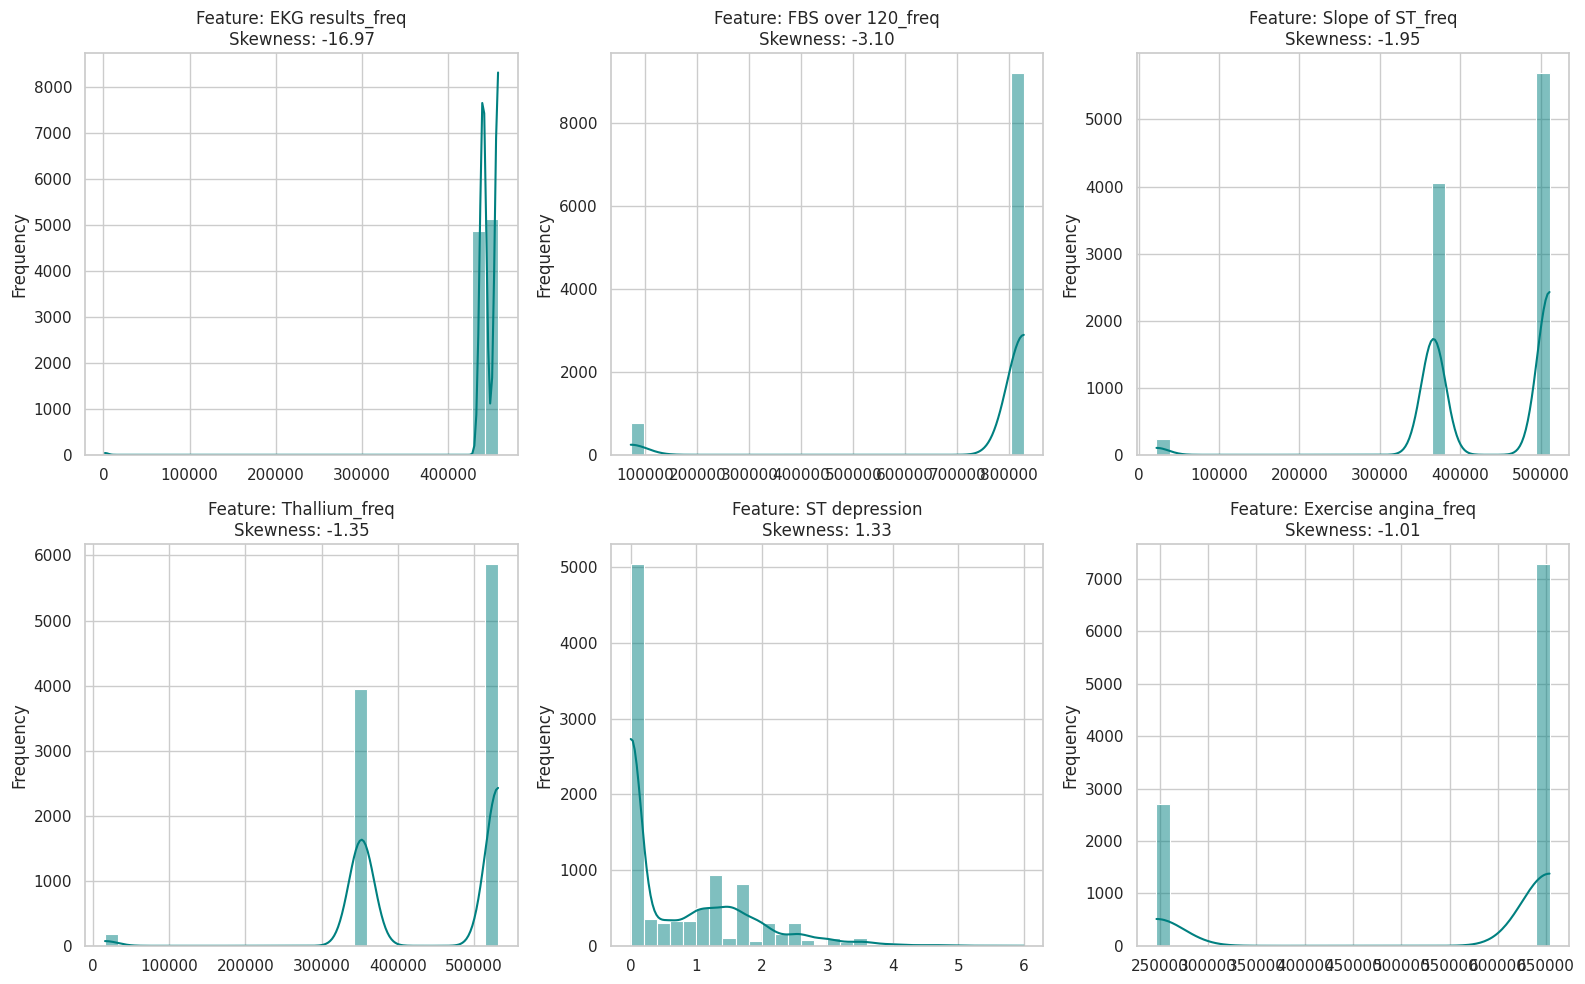

In [10]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

skew_series = X[numeric_cols].skew().abs().sort_values(ascending=False)
top_skewed_features = skew_series.head(6).index.tolist()

print("Top 6 Most Skewed Features (Absolute Values):")
print(X[top_skewed_features].skew())

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_skewed_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(X[col].sample(min(10000, len(X))), kde=True, color='teal', bins=30)
    plt.title(f"Feature: {col}\nSkewness: {X[col].skew():.2f}")
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Cross-Validation & Training

In [14]:
%%time

# =========================
# Fixed params (Best from HPO)
# =========================
N_FOLDS = 5
RANDOM_STATE = 42
PRIMARY_CONFIG = "numeric_continuous"

params = {
    "device": DEVICE,              # "cuda" or "cpu"
    "random_state": RANDOM_STATE,
    "verbosity": 2,

    # training
    "n_epochs": 100,

    # best params (from your Optuna best)
    "batch_size": 2**12, # 128 or 512
    "n_ens": 12, # number of model: 8 or 12
    "act": "relu", # relu or mish
    "embedding_size": 4,
    "first_layer_lr_factor": 0.4909517357192525,
    "hidden_sizes": "rectangular",
    "hidden_width": 256,
    "lr": 0.009998859607801438, # 0.04 or 0.009
    "ls_eps": 0.010126807777508847,
    "ls_eps_sched": "coslog4",
    "max_one_hot_cat_size": 19,
    "n_hidden_layers": 6,
    "p_drop": 0.29904893015047485, #  0.07 or 0.02
    "p_drop_sched": "flat",
    "plr_hidden_1": 32,
    "plr_hidden_2": 8,
    "plr_lr_factor": 0.045999072301917396,
    "plr_sigma": 3.0846208639928108,
    "scale_lr_factor": 4.5960005947548925,
    "wd": 0.04967881042787047,

    # early stopping (best params)
    "use_early_stopping": True,
    "early_stopping_additive_patience": 20,
    "early_stopping_multiplicative_patience": 1.0,

    "val_metric_name": "1-auc_ovo",  # AUCベースでbest epoch選択
}

print("Using fixed params (submission-style):")
display(pd.Series(params))


Using fixed params (submission-style):


,0
device,cuda
random_state,42
verbosity,2
n_epochs,100
batch_size,4096
n_ens,12
act,relu
embedding_size,4
first_layer_lr_factor,0.490952
hidden_sizes,rectangular


CPU times: user 5.44 ms, sys: 928 µs, total: 6.37 ms
Wall time: 13 ms


In [15]:
import time
from datetime import datetime
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

feat = features[PRIMARY_CONFIG]
X = feat["X"].copy()
X_test = feat["X_test"].copy()
y = feat["y"].copy()

for col in feat["cat_cols"]:
    X[col] = X[col].astype(str).astype("category")
    X_test[col] = X_test[col].astype(str).astype("category")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(X), dtype=np.float32)
test_preds = np.zeros(len(X_test), dtype=np.float32)
fold_scores = []

t_total_start = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    t_fold_start = time.time()

    # ── フォールド開始ログ ──────────────────────────────
    print(f"\n{'='*55}")
    print(f"  Fold {fold}/{N_FOLDS}  |  started at {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*55}")

    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]

    SUB_FRAC = 0.3
    sss = StratifiedShuffleSplit(
        n_splits=1,
        train_size=int(len(X_tr) * SUB_FRAC),
        random_state=RANDOM_STATE + fold
    )
    sub_idx, _ = next(sss.split(X_tr, y_tr))
    X_tr = X_tr.iloc[sub_idx]
    y_tr = y_tr.iloc[sub_idx]

    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    print(f"  [data]  train={len(X_tr):,}  val={len(X_val):,}  "
          f"pos_rate(tr)={y_tr.mean():.3f}  pos_rate(val)={y_val.mean():.3f}")

    # ── モデル学習 ──────────────────────────────────────
    print(f"  [fit]   starting RealMLP_TD training ...")
    t_fit = time.time()
    model = RealMLP_TD_Classifier(**params)
    model.fit(X_tr, y_tr.values, X_val, y_val.values)
    print(f"  [fit]   done in {time.time()-t_fit:.1f}s")

    # ── 予測 ────────────────────────────────────────────
    print(f"  [pred]  predicting val & test ...")
    val_probs  = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    oof_preds[val_idx] = val_probs
    test_preds += test_probs / N_FOLDS

    # ── フォールドスコア ─────────────────────────────────
    score = roc_auc_score(y_val, val_probs)
    fold_scores.append(score)
    elapsed = time.time() - t_fold_start
    total_elapsed = time.time() - t_total_start

    eta = (total_elapsed / fold) * (N_FOLDS - fold)  # 残り時間推定

    print(f"\n  Fold {fold} AUC : {score:.5f}")
    print(f"  Scores so far : {[round(s,5) for s in fold_scores]}")
    print(f"  Running mean  : {np.mean(fold_scores):.5f}  ±  {np.std(fold_scores):.5f}")
    print(f"  Fold time     : {elapsed:.1f}s  |  Total: {total_elapsed:.1f}s  |  ETA: {eta:.1f}s")

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        print("  [cuda]  cache cleared")

# ── 最終サマリー ──────────────────────────────────────
total_time = time.time() - t_total_start
mean_auc = float(np.mean(fold_scores))
std_auc  = float(np.std(fold_scores))
oof_auc  = float(roc_auc_score(y, oof_preds))

print(f"\n{'#'*55}")
print(f"  CV SUMMARY")
print(f"{'#'*55}")
print(f"  Fold scores : {[round(s,6) for s in fold_scores]}")
print(f"  Mean AUC    : {mean_auc:.6f}")
print(f"  Std AUC     : {std_auc:.6f}")
print(f"  OOF AUC     : {oof_auc:.6f}")
print(f"  Total time  : {total_time:.1f}s  ({total_time/60:.1f}min)")
print(f"{'#'*55}")


  Fold 1/5  |  started at 07:05:54
  [data]  train=151,200  val=126,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq']
Columns classified as categorical: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/100: val class_error = 0.234571
Epoch 2/100: val class_error = 0.124206
Epoch 3/100: val class_error = 0.117929
Epoch 4/100: val class_error = 0.115405
Epoch 5/100: val class_error = 0.114849
Epoch 6/100: val class_error = 0.114794
Epoch 7/100: val class_error = 0.114532
Epoch 8/100: val class_error = 0.114651
Epoch 9/100: val class_error = 0.114119
Epoch 10/100: val class_error = 0.113548
Epoch 11/100: val class_error = 0.113254
Epoch 12/100: val class_error = 0.112548
Epoch 13/100: val class_error = 0.112714
Epoch 14/100: val class_error = 0.112556
Epoch 15/100: val class_error = 0.112579
Epoch 16/100: val class_error = 0.112452
Epoch 17/100: val class_error = 0.112270
Epoch 18/100: val class_error = 0.112365
Epoch 19/100: val class_error = 0.112476
Epoch 20/100: val class_error = 0.112460
Epoch 21/100: val class_error = 0.112508
Epoch 22/100: val class_error = 0.112516
Epoch 23/100: val class_error = 0.112444
Epoch 24/100: val class_error = 0.112349
Epoch 25/100: val class_e

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cud


  Fold 1 AUC : 0.95509
  Scores so far : [np.float64(0.95509)]
  Running mean  : 0.95509  ±  0.00000
  Fold time     : 428.9s  |  Total: 429.0s  |  ETA: 1715.9s
  [cuda]  cache cleared

  Fold 2/5  |  started at 07:13:03
  [data]  train=151,200  val=126,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq']
Columns classified as categorical: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


...


  Fold 4 AUC : 0.95426
  Scores so far : [np.float64(0.95509), np.float64(0.95398), np.float64(0.9548), np.float64(0.95426)]
  Running mean  : 0.95453  ±  0.00043
  Fold time     : 270.6s  |  Total: 1613.9s  |  ETA: 403.5s
  [cuda]  cache cleared

  Fold 5/5  |  started at 07:32:48
  [data]  train=151,200  val=126,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq']
Columns classified as categorical: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/100: val class_error = 0.142714
Epoch 2/100: val class_error = 0.123540
Epoch 3/100: val class_error = 0.116302
Epoch 4/100: val class_error = 0.114619
Epoch 5/100: val class_error = 0.114341
Epoch 6/100: val class_error = 0.114230
Epoch 7/100: val class_error = 0.114175
Epoch 8/100: val class_error = 0.113992
Epoch 9/100: val class_error = 0.114008
Epoch 10/100: val class_error = 0.113556
Epoch 11/100: val class_error = 0.113286
Epoch 12/100: val class_error = 0.113206
Epoch 13/100: val class_error = 0.112976
Epoch 14/100: val class_error = 0.112810
Epoch 15/100: val class_error = 0.112540
Epoch 16/100: val class_error = 0.112460
Epoch 17/100: val class_error = 0.112389
Epoch 18/100: val class_error = 0.112357
Epoch 19/100: val class_error = 0.112341
Epoch 20/100: val class_error = 0.112325
Epoch 21/100: val class_error = 0.112341
Epoch 22/100: val class_error = 0.112341
Epoch 23/100: val class_error = 0.112437
Epoch 24/100: val class_error = 0.112238
Epoch 25/100: val class_e

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cud


  Fold 5 AUC : 0.95505
  Scores so far : [np.float64(0.95509), np.float64(0.95398), np.float64(0.9548), np.float64(0.95426), np.float64(0.95505)]
  Running mean  : 0.95463  ±  0.00044
  Fold time     : 296.4s  |  Total: 1910.3s  |  ETA: 0.0s
  [cuda]  cache cleared

#######################################################
  CV SUMMARY
#######################################################
  Fold scores : [np.float64(0.955087), np.float64(0.953979), np.float64(0.954797), np.float64(0.954262), np.float64(0.955047)]
  Mean AUC    : 0.954635
  Std AUC     : 0.000440
  OOF AUC     : 0.954304
  Total time  : 1910.3s  (31.8min)
#######################################################


### Model Evaluation

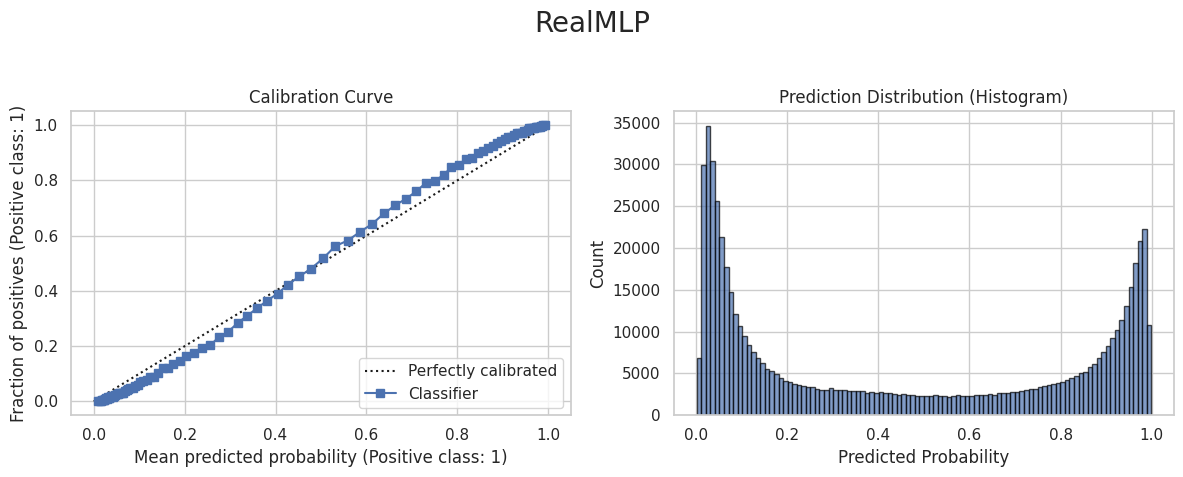

In [16]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(12, 5))
plt.suptitle('RealMLP', fontsize=20)

ax1 = plt.subplot(1, 2, 1)
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=100, strategy='quantile', ax=ax1)
ax1.set_title('Calibration Curve')

ax2 = plt.subplot(1, 2, 2)
ax2.hist(oof_preds, bins=100, edgecolor='black', alpha=0.7)
ax2.set_title('Prediction Distribution (Histogram)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

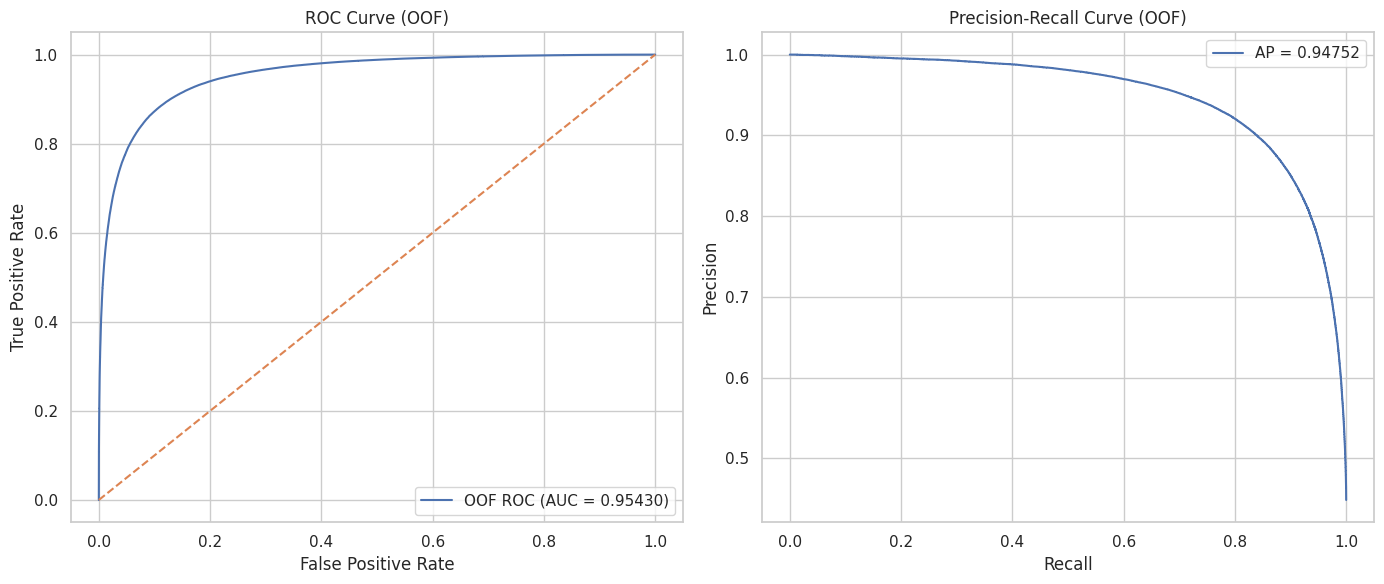

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Create figure with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y, oof_preds)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, label=f'OOF ROC (AUC = {roc_auc:.5f})')
ax1.plot([0, 1], [0, 1], linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve (OOF)')
ax1.legend()
ax1.grid(True)

# ---- Precision-Recall Curve ----
precision, recall, _ = precision_recall_curve(y, oof_preds)
ap = average_precision_score(y, oof_preds)

ax2.plot(recall, precision, label=f'AP = {ap:.5f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve (OOF)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


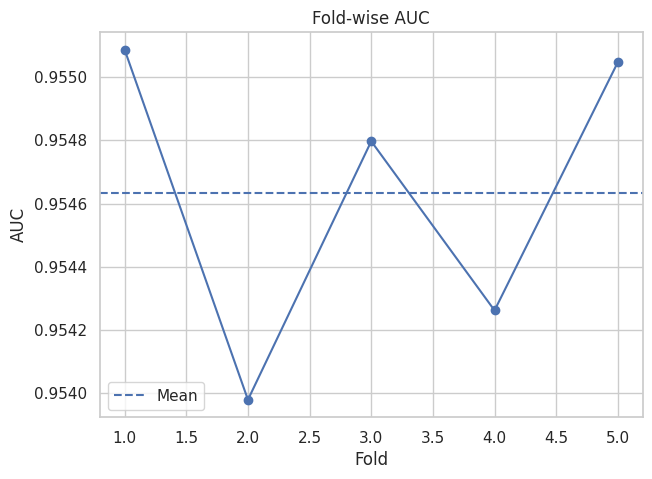

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, N_FOLDS+1), fold_scores, marker='o')
plt.axhline(np.mean(fold_scores), linestyle='--', label='Mean')

plt.xlabel('Fold')
plt.ylabel('AUC')
plt.title('Fold-wise AUC')
plt.legend()
plt.grid(True)
plt.show()


### Evaluation and Submission

In [ ]:
total_oof_score = roc_auc_score(y, oof_preds)

print("\n" + "="*40)
print(f"Overall OOF ROC-AUC (avg OOF): {total_oof_score:.5f}")
print("="*40)


In [ ]:
# Fold Scores Table
fold_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(fold_scores))],
    "ROC-AUC": fold_scores,
})
fold_df


In [ ]:
submission = pd.DataFrame({'id': test['id'], 'Heart Disease': test_preds})
submission.to_csv('submission.csv', index=False)

print('Submission saved!')
print(f'Shape: {submission.shape}')

if len(submission) != 270000:
    raise ValueError(f"CRITICAL ERROR: Submission row count {len(submission)} != expected 270000")

submission.head()